<a href="https://colab.research.google.com/github/hewettac/OOP-New/blob/main/TemplinB_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Connect Drive to Colab to import data straight from drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


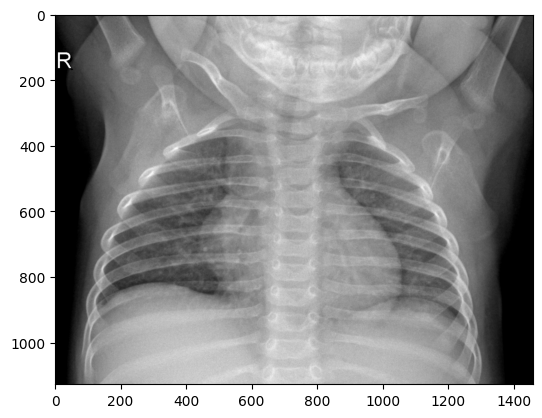

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

DATADIR = "/content/drive/MyDrive/Machine_Learning/chest_xray_files"
CATEGORIES = ["NORMAL", "PNEUMONIA"]

for category in CATEGORIES:
  path = os.path.join(DATADIR, category)
  for image in os.listdir(path):
    image_array = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
    plt.imshow(image_array, cmap = "gray")
    plt.show()
    break
  break


In [4]:
#print(image_array.shape)

#IMAGE_SIZE = 224

#new_array = cv2.resize(image_array, (IMAGE_SIZE, IMAGE_SIZE))
#plt.imshow(new_array, cmap = "gray")
#plt.show()

In [5]:
training_data =  []
IMAGE_SIZE = 224        # Adjust as needed


def create_training_data():
  for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    class_num = CATEGORIES.index(category)
    for image in os.listdir(path):
      image_array = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
      new_array = cv2.resize(image_array, (IMAGE_SIZE, IMAGE_SIZE))
      training_data.append([new_array, class_num])

create_training_data()
print(len(training_data))

5218


In [6]:
import random

random.shuffle(training_data)

In [7]:
for sample in training_data[:10]:
  print(sample[1])

1
1
0
1
1
1
1
1
0
1


In [8]:
X = []
y = []

In [9]:
for features, label in training_data:
  X.append(features)
  y.append(label)

X = np.array(X).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)      # (All Images, Image Height, Image Width, Greyscale)
y = np.array(y)

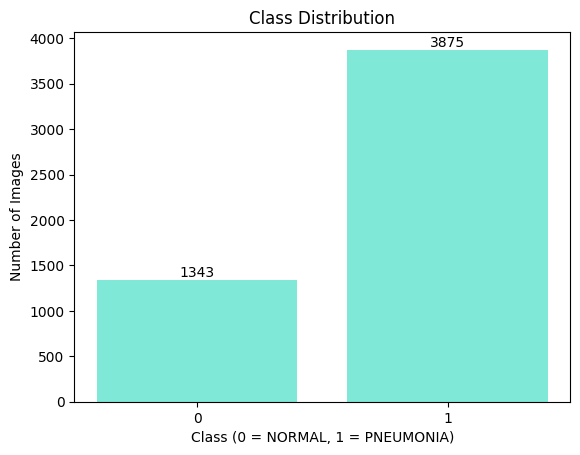

In [10]:
classes, counts = np.unique(y, return_counts=True)

plt.figure()

bars = plt.bar(classes.astype(str), counts, color="#7FE8D7")

plt.title("Class Distribution")
plt.xlabel("Class (0 = NORMAL, 1 = PNEUMONIA)")
plt.ylabel("Number of Images")

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
# Computes the Weights for Class Imbalance

from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y), class_weights_arr)}

print("Class Weights:", class_weight)

Class Weights: {0: 1.9426656738644825, 1: 0.6732903225806451}


In [ ]:
import pickle

pickle_out = open("X.pickle", "wb")
pickle.dump(X, pickle_out)
pickle_out.close()

pickle_out = open("y.pickle", "wb")
pickle.dump(y, pickle_out)
pickle_out.close()

In [ ]:
####################################

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

X = pickle.load(open("X.pickle", "rb"))
y = pickle.load(open("y.pickle", "rb"))

X = X/255                                                 # Add image augmentations after this

model = Sequential()

model.add(Conv2D(64, (3,3), input_shape = X.shape[1:]))   # (Number of Filters, (Sliding Window Size))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))                # Maybe add Strides

model.add(Conv2D(64, (3,3)))
model.add(Activation("relu"))                             # Sigmoid vs Relu vs SoftMax (If split to 3)
model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Flatten())                                      # Global Image Pooling Maybe Instead of Flatten (This Overfits)

model.add(Dense(64))                                      # Add Dropout as Well Somewhere
model.add(Activation("relu"))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss = "binary_crossentropy",               # categorical_crossentropy if 3 types
              optimizer = "adam",
              metrics = ['accuracy'])

model.fit(X, y, batch_size = 32, epochs = 1, validation_split = 0.1)      # Add Class weights here for imbalance

model.save("CNN_base.keras")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


147/147 ━━━━━━━━━━━━━━━━━━━━ 676s 5s/step - accuracy: 0.7715 - loss: 0.5586 - val_accuracy: 0.9502 - val_loss: 0.1237


In [ ]:
####################################

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, Input, RandomRotation, RandomZoom, RandomTranslation, RandomContrast)

X = pickle.load(open("X.pickle", "rb"))
y = pickle.load(open("y.pickle", "rb"))

X = X/255                                                 ### highest pixel value (standardize)

model = Sequential()

model.add(Input(shape=X.shape[1:]))                       ### image augmentations

model.add(RandomRotation(0.05))
model.add(RandomZoom(0.10))                               # adjust to see what happens
model.add(RandomTranslation(0.05, 0.05))
model.add(RandomContrast(0.10))

model.add(Conv2D(64, (3,3), input_shape = X.shape[1:]))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size = (2,2)))                # Maybe add Strides

model.add(Conv2D(64, (3,3)))
model.add(Activation("relu"))                             # Sigmoid vs Relu vs SoftMax (If split to 3)
model.add(MaxPooling2D(pool_size = (2,2)))

model.add(Flatten())                                      # Global Image Pooling Maybe Instead of Flatten (This Overfits)

model.add(Dense(64))                                      # Add Dropout as Well Somewhere
model.add(Activation("relu"))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss = "binary_crossentropy",               # categorical_crossentropy if 3 types
              optimizer = "adam",
              metrics = ['accuracy'])

model.fit(X, y, batch_size = 32, epochs = 3, validation_split = 0.1, class_weight = class_weight)   ### class weights here
                                                                                                    # change epochs to 3
model.save("CNN_revised.keras")

# look into test data set, and if it is necessary
# Build a prediction part to put in images to see what they score
# If time make changes to single hashtags
# bacterial vs viral treatment plan (is different?)
# ask dad for xray if possible
# https://www.youtube.com/watch?v=A4K6D_gx2Iw&list=PLQVvvaa0QuDfhTox0AjmQ6tvTgMBZBEXN&index=6

Epoch 1/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 719s 5s/step - accuracy: 0.5295 - loss: 0.7848 - val_accuracy: 0.8621 - val_loss: 0.3630
Epoch 2/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 702s 5s/step - accuracy: 0.8504 - loss: 0.3312 - val_accuracy: 0.9330 - val_loss: 0.1798
Epoch 3/3
147/147 ━━━━━━━━━━━━━━━━━━━━ 716s 5s/step - accuracy: 0.8745 - loss: 0.3133 - val_accuracy: 0.9406 - val_loss: 0.1433


In [ ]:
############# PREDICTION STUFF

In [1]:
from tensorflow.keras.models import load_model

cnn_model = load_model("CNN_revised.keras")

ValueError: File not found: filepath=CNN_revised.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
def prepare_image(filepath):
    IMAGE_SIZE = 224

    img_array = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img_array, (IMAGE_SIZE, IMAGE_SIZE))

    img_normalized = img_resized / 255.0

    img_reshaped = img_normalized.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)

    return img_reshaped

In [ ]:
# test with an image
image_path = "/content/drive/MyDrive/Machine_Learning/chest_xray_files/NORMAL/IM-0115-0001.jpeg"

prediction = cnn_model.predict(prepare_image(image_path))
score = float(prediction[0][0])   # probability of pneumonia

# the higher the score, the more likely there is pneumonia
# adjust cutoff value

if score > 0.5:
    label = "PNEUMONIA"
else:
    label = "NORMAL"

print(f"Prediction: {label}")
print(f"Pneumonia Probability: {score:.10f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Prediction: NORMAL
Pneumonia Probability: 0.0164575670


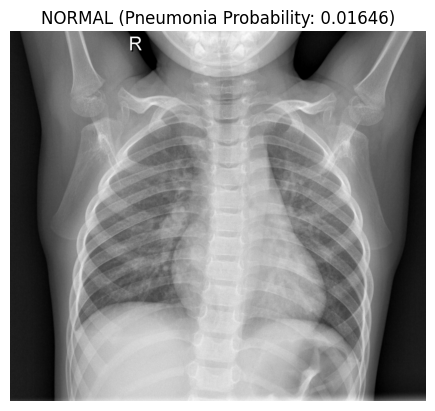

In [ ]:
# print image with classification and probability score

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title(f"{label} (Pneumonia Probability: {score:.5f})")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Prediction: PNEUMONIA
Pneumonia Probability: 0.7165888548


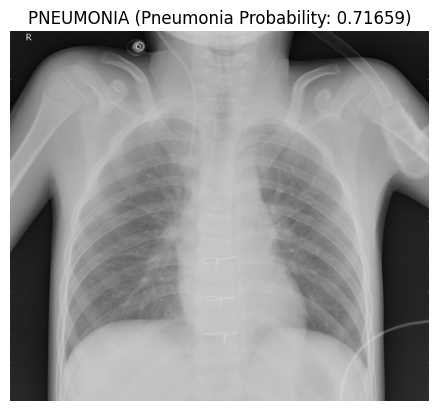

In [ ]:
# try again with a case of pneumonia
image_path = "/content/drive/MyDrive/Machine_Learning/chest_xray_files/PNEUMONIA/person21_bacteria_72.jpeg"

prediction = cnn_model.predict(prepare_image(image_path))
score = float(prediction[0][0])

if score > 0.5:
    label = "PNEUMONIA"
else:
    label = "NORMAL"

print(f"Prediction: {label}")
print(f"Pneumonia Probability: {score:.10f}")


img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title(f"{label} (Pneumonia Probability: {score:.5f})")
plt.axis("off")
plt.show()